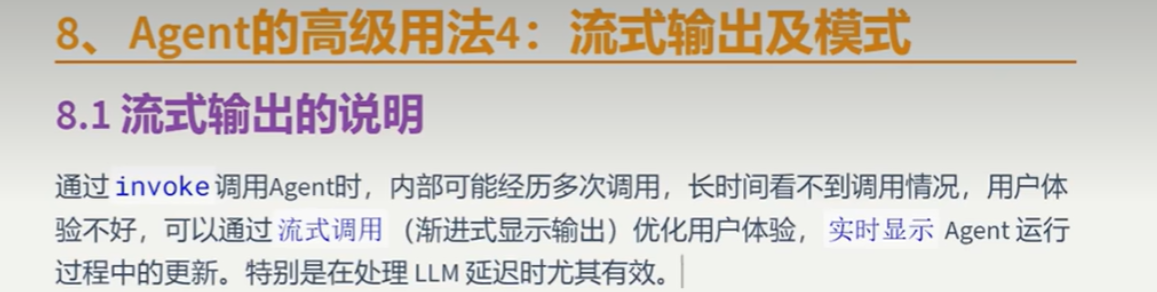

## 8.2 具体的输出模式
### values输出模式
#### stream_mode="values"

In [1]:
from langchain_core.tools import tool
from typing import Union, Dict, Any

from langchain.agents.structured_output import ToolStrategy,MultipleStructuredOutputsError,StructuredOutputValidationError
from langgraph.checkpoint.memory import InMemorySaver
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    # model="carstenuhlig/omnicoder-9b:latest",
    model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

## 2.定义工具
@tool
def query_customer_data(customer_id: str) -> Dict[str,Any]:
       """
       查询客户基本信息

       Args:
              customer_id:  客户ID，用来唯一标识客户

       Returns:
               包含客户基本信息的字典，如姓名、等级，加入日期等
       """
       # 模拟数据库查询
       return {"name":"张三","level":"VIP","join_date":"2023-01-15"}

@tool
def check_order_history(customer_id: str) -> Dict[str,Any]:
       """
       查询客户订单历史

       Args:
              customer_id:  客户ID，用来唯一标识客户

       Returns:
             包含客户订单历史的字典，如总订单数，总花费等
       """
       return {"total_orders":15,"total_spent":25800.00}

@tool
def get_current_promotions() ->Dict[str,Any]:
     """
     获取当前可以促销活动

     Returns:
            包含当前可用促销活动的字典，如活动名称，邮箱日期等
     """
     return {
            "promotions":["老用户优惠","会员专属折扣"],
            "valid_until":"2027-01-31"
    }

agent = create_agent(
    model=model,
    tools=[query_customer_data,check_order_history, get_current_promotions]
)

for chunk in agent.stream({
    "messages":[{
        "role":"user",
        "content":"查询客户ID为CUST123456的个人信息、历史订单和可用优惠"
    }]
},stream_mode="values"):
    rprint(chunk)
    print("-"*50)



{
    'messages': [
        HumanMessage(
            content='查询客户ID为CUST123456的个人信息、历史订单和可用优惠',
            additional_kwargs={},
            response_metadata={},
            id='61ebdadf-78e5-46de-b295-c97cd7a261d5'
        )
    ]
}

--------------------------------------------------


{
    'messages': [
        HumanMessage(
            content='查询客户ID为CUST123456的个人信息、历史订单和可用优惠',
            additional_kwargs={},
            response_metadata={},
            id='61ebdadf-78e5-46de-b295-c97cd7a261d5'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 460,
                    'prompt_tokens': 377,
                    'total_tokens': 837,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-511',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a11937-a3d1-7081-ae90-d9258025ec84-0',
            tool_calls=[
                {
                    'name': 'query_customer_data',
                    'args': {'customer_id': 'CUST123456'},
                    'id': 'call_fsms8qkw',
                    'type': 'tool_call'
                },
                {
                    'name': 'check_order_history',
                    'args': {'customer_id': 'CUST123456'},
                    'id': 'call_vk8u2x96',
                    'type': 'tool_call'
                },
                {'name': 'get_current_promotions', 'args': {}, 'id': 'call_o29zok8h', 'type': 'tool_call'}
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 377,
                'output_tokens': 460,
                'total_tokens': 837,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        )
    ]
}

--------------------------------------------------


{
    'messages': [
        HumanMessage(
            content='查询客户ID为CUST123456的个人信息、历史订单和可用优惠',
            additional_kwargs={},
            response_metadata={},
            id='61ebdadf-78e5-46de-b295-c97cd7a261d5'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 460,
                    'prompt_tokens': 377,
                    'total_tokens': 837,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-511',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a11937-a3d1-7081-ae90-d9258025ec84-0',
            tool_calls=[
                {
                    'name': 'query_customer_data',
                    'args': {'customer_id': 'CUST123456'},
                    'id': 'call_fsms8qkw',
                    'type': 'tool_call'
                },
                {
                    'name': 'check_order_history',
                    'args': {'customer_id': 'CUST123456'},
                    'id': 'call_vk8u2x96',
                    'type': 'tool_call'
                },
                {'name': 'get_current_promotions', 'args': {}, 'id': 'call_o29zok8h', 'type': 'tool_call'}
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 377,
                'output_tokens': 460,
                'total_tokens': 837,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='{"name": "张三", "level": "VIP", "join_date": "2023-01-15"}',
            name='query_customer_data',
            id='4f8ceee6-c34b-48db-9cc2-02cdae4eb232',
            tool_call_id='call_fsms8qkw'
        ),
        ToolMessage(
            content='{"total_orders": 15, "total_spent": 25800.0}',
            name='check_order_history',
            id='75161cbd-3d86-4519-b97c-046ce10e3984',
            tool_call_id='call_vk8u2x96'
        ),
        ToolMessage(
            content='{"promotions": ["老用户优惠", "会员专属折扣"], "valid_until": "2027-01-31"}',
            name='get_current_promotions',
            id='7389192d-5617-47a0-b371-ff188fade96b',
            tool_call_id='call_o29zok8h'
        )
    ]
}

--------------------------------------------------


{
    'messages': [
        HumanMessage(
            content='查询客户ID为CUST123456的个人信息、历史订单和可用优惠',
            additional_kwargs={},
            response_metadata={},
            id='61ebdadf-78e5-46de-b295-c97cd7a261d5'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 460,
                    'prompt_tokens': 377,
                    'total_tokens': 837,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-511',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a11937-a3d1-7081-ae90-d9258025ec84-0',
            tool_calls=[
                {
                    'name': 'query_customer_data',
                    'args': {'customer_id': 'CUST123456'},
                    'id': 'call_fsms8qkw',
                    'type': 'tool_call'
                },
                {
                    'name': 'check_order_history',
                    'args': {'customer_id': 'CUST123456'},
                    'id': 'call_vk8u2x96',
                    'type': 'tool_call'
                },
                {'name': 'get_current_promotions', 'args': {}, 'id': 'call_o29zok8h', 'type': 'tool_call'}
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 377,
                'output_tokens': 460,
                'total_tokens': 837,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='{"name": "张三", "level": "VIP", "join_date": "2023-01-15"}',
            name='query_customer_data',
            id='4f8ceee6-c34b-48db-9cc2-02cdae4eb232',
            tool_call_id='call_fsms8qkw'
        ),
        ToolMessage(
            content='{"total_orders": 15, "total_spent": 25800.0}',
            name='check_order_history',
            id='75161cbd-3d86-4519-b97c-046ce10e3984',
            tool_call_id='call_vk8u2x96'
        ),
        ToolMessage(
            content='{"promotions": ["老用户优惠", "会员专属折扣"], "valid_until": "2027-01-31"}',
            name='get_current_promotions',
            id='7389192d-5617-47a0-b371-ff188fade96b',
            tool_call_id='call_o29zok8h'
        ),
        AIMessage(
            content='客户ID为CUST123456的完整信息如下：\n\n**1. 个人信息**\n- 姓名：张三\n- 会员等级：VIP\n- 
加入日期：2023年1月15日\n\n**2. 订单历史**\n- 总订单数：15单\n- 总消费金额：25,800.00元\n\n**3. 当前可用优惠**\n- 
活动名称：老用户优惠、会员专属折扣\n- 有效期至：2027年1月31日\n\n需要为您生成详细报告或进一步协助吗？',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 410,
                    'prompt_tokens': 554,
                    'total_tokens': 964,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-662',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a1193d-d1ad-7800-8273-ee16bdb441a4-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 554,
                'output_tokens': 410,
                'total_tokens': 964,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        )
    ]
}

--------------------------------------------------


### updates模式
stream_mode="updates"

In [1]:
from langchain_core.tools import tool
from typing import Union, Dict, Any
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    # model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    model="483025889/qwen3.5:9b",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

## 2.定义工具
@tool
def query_customer_data(customer_id: str) -> Dict[str,Any]:
       """
       查询客户基本信息

       Args:
              customer_id:  客户ID，用来唯一标识客户

       Returns:
               包含客户基本信息的字典，如姓名、等级，加入日期等
       """
       # 模拟数据库查询
       return {"name":"张三","level":"VIP","join_date":"2023-01-15"}

@tool
def check_order_history(customer_id: str) -> Dict[str,Any]:
       """
       查询客户订单历史

       Args:
              customer_id:  客户ID，用来唯一标识客户

       Returns:
             包含客户订单历史的字典，如总订单数，总花费等
       """
       return {"total_orders":15,"total_spent":25800.00}

@tool
def get_current_promotions() ->Dict[str,Any]:
     """
     获取当前可以促销活动

     Returns:
            包含当前可用促销活动的字典，如活动名称，邮箱日期等
     """
     return {
            "promotions":["老用户优惠","会员专属折扣"],
            "valid_until":"2027-01-31"
    }

agent = create_agent(
    model=model,
    tools=[query_customer_data,check_order_history, get_current_promotions]
)

for chunk in agent.stream({
    "messages":[{
        "role":"user",
        "content":"查询客户ID为CUST123456的个人信息、历史订单和可用优惠"
    }]
},stream_mode="updates"):
    rprint(chunk)
    print("-"*50)



{
    'model': {
        'messages': [
            AIMessage(
                content='',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 187,
                        'prompt_tokens': 486,
                        'total_tokens': 673,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                    },
                    'model_provider': 'openai',
                    'model_name': '483025889/qwen3.5:9b',
                    'system_fingerprint': 'fp_ollama',
                    'id': 'chatcmpl-895',
                    'finish_reason': 'tool_calls',
                    'logprobs': None
                },
                id='lc_run--01a1230c-3250-7993-8d7b-7c3b773b8d06-0',
                tool_calls=[
                    {
                        'name': 'query_customer_data',
                        'args': {'customer_id': 'CUST123456'},
                        'id': 'call_zkh1j6mh',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'check_order_history',
                        'args': {'customer_id': 'CUST123456'},
                        'id': 'call_56uox8bd',
                        'type': 'tool_call'
                    },
                    {'name': 'get_current_promotions', 'args': {}, 'id': 'call_go62gmyn', 'type': 'tool_call'}
                ],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 486,
                    'output_tokens': 187,
                    'total_tokens': 673,
                    'input_token_details': {'cache_read': 0},
                    'output_token_details': {}
                }
            )
        ]
    }
}

--------------------------------------------------


{
    'tools': {
        'messages': [
            ToolMessage(
                content='{"total_orders": 15, "total_spent": 25800.0}',
                name='check_order_history',
                id='7b52e163-a23c-4d44-8ae4-b7bb51cc2b4d',
                tool_call_id='call_56uox8bd'
            )
        ]
    }
}

--------------------------------------------------


{
    'tools': {
        'messages': [
            ToolMessage(
                content='{"name": "张三", "level": "VIP", "join_date": "2023-01-15"}',
                name='query_customer_data',
                id='a0f2ee72-bc79-497e-a4cd-5d1ee9f2e1cd',
                tool_call_id='call_zkh1j6mh'
            )
        ]
    }
}

--------------------------------------------------


{
    'tools': {
        'messages': [
            ToolMessage(
                content='{"promotions": ["老用户优惠", "会员专属折扣"], "valid_until": "2027-01-31"}',
                name='get_current_promotions',
                id='4f934fed-1966-4c28-a674-fbb42b3b9859',
                tool_call_id='call_go62gmyn'
            )
        ]
    }
}

--------------------------------------------------


{
    'model': {
        'messages': [
            AIMessage(
                content='以下是关于客户ID为CUST123456的查询结果：\n\n**个人基本信息：**\n*   **姓名**：张三\n*   
**等级**：VIP\n*   **加入日期**：2023-01-15\n\n**历史订单记录：**\n*   **总订单数**：15次\n*   
**累计消费金额**：¥25,800.0\n\n**可用促销活动：**\n*   老用户优惠\n*   会员专属折扣\n    *   
(注：优惠活动有效期至2027-01-31)',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 301,
                        'prompt_tokens': 680,
                        'total_tokens': 981,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 482}
                    },
                    'model_provider': 'openai',
                    'model_name': '483025889/qwen3.5:9b',
                    'system_fingerprint': 'fp_ollama',
                    'id': 'chatcmpl-715',
                    'finish_reason': 'stop',
                    'logprobs': None
                },
                id='lc_run--01a1230d-8549-7390-9b50-ce50091567a2-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 680,
                    'output_tokens': 301,
                    'total_tokens': 981,
                    'input_token_details': {'cache_read': 482},
                    'output_token_details': {}
                }
            )
        ]
    }
}

--------------------------------------------------


### stream_mode="messages"

In [9]:
from langchain_core.tools import tool
from typing import Union, Dict, Any
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    # model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    model="483025889/qwen3.5:9b",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

## 2.定义工具
@tool
def query_customer_data(customer_id: str) -> Dict[str,Any]:
       """
       查询客户基本信息

       Args:
              customer_id:  客户ID，用来唯一标识客户

       Returns:
               包含客户基本信息的字典，如姓名、等级，加入日期等
       """
       # 模拟数据库查询
       return {"name":"张三","level":"VIP","join_date":"2023-01-15"}

@tool
def check_order_history(customer_id: str) -> Dict[str,Any]:
       """
       查询客户订单历史

       Args:
              customer_id:  客户ID，用来唯一标识客户

       Returns:
             包含客户订单历史的字典，如总订单数，总花费等
       """
       return {"total_orders":15,"total_spent":25800.00}

@tool
def get_current_promotions() ->Dict[str,Any]:
     """
     获取当前可以促销活动

     Returns:
            包含当前可用促销活动的字典，如活动名称，邮箱日期等
     """
     return {
            "promotions":["老用户优惠","会员专属折扣"],
            "valid_until":"2027-01-31"
    }

agent = create_agent(
    model=model,
    tools=[query_customer_data,check_order_history, get_current_promotions]
)

for chunk in agent.stream({
    "messages":[{
        "role":"user",
        "content":"查询客户ID为CUST123456的个人信息、历史订单和可用优惠"
    }]
},stream_mode="messages"):
    # rprint(chunk)
    # print("-"*50)
    print(chunk[0].content,end="" ,flush=True)



{"total_orders": 15, "total_spent": 25800.0}{"name": "张三", "level": "VIP", "join_date": "2023-01-15"}{"promotions": ["老用户优惠", "会员专属折扣"], "valid_until": "2027-01-31"}以下是为您查询到的客户 CUST123456 的综合信息：

### 📇 客户基本信息
*   **姓名**：张三
*   **等级**：VIP（高级会员）
*   **加入日期**：2023年1月15日

### 🛒 历史订单记录
*   **总订单数**：15 单
*   **累计消费**：¥25,800.00

### 🎁 当前可用优惠活动
截至 2027年1月31日，您可以享受以下促销权益：
1.  **老用户优惠**
2.  **会员专属折扣**

由于您是 VIP 高级会员且是老用户，建议您在使用服务时主动咨询并使用上述两项优惠以提升收益。

### stream_mode="tasks"

In [13]:
from langchain_core.tools import tool
from typing import Union, Dict, Any
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    # model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    model="483025889/qwen3.5:9b",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

## 2.定义工具
@tool
def query_customer_data(customer_id: str) -> Dict[str,Any]:
       """
       查询客户基本信息

       Args:
              customer_id:  客户ID，用来唯一标识客户

       Returns:
               包含客户基本信息的字典，如姓名、等级，加入日期等
       """
       # 模拟数据库查询
       return {"name":"张三","level":"VIP","join_date":"2023-01-15"}

@tool
def check_order_history(customer_id: str) -> Dict[str,Any]:
       """
       查询客户订单历史

       Args:
              customer_id:  客户ID，用来唯一标识客户

       Returns:
             包含客户订单历史的字典，如总订单数，总花费等
       """
       return {"total_orders":15,"total_spent":25800.00}

@tool
def get_current_promotions() ->Dict[str,Any]:
     """
     获取当前可以促销活动

     Returns:
            包含当前可用促销活动的字典，如活动名称，邮箱日期等
     """
     return {
            "promotions":["老用户优惠","会员专属折扣"],
            "valid_until":"2027-01-31"
    }

agent = create_agent(
    model=model,
    tools=[query_customer_data,check_order_history, get_current_promotions]
)

for chunk in agent.stream({
    "messages":[{
        "role":"user",
        "content":"查询客户ID为CUST123456的个人信息、历史订单和可用优惠"
    }]
},stream_mode="tasks"):
    rprint(chunk)
    print("-"*50)



{
    'id': '02abd369-3187-eaff-4fa6-d628bc163523',
    'name': 'model',
    'input': {
        'messages': [
            HumanMessage(
                content='查询客户ID为CUST123456的个人信息、历史订单和可用优惠',
                additional_kwargs={},
                response_metadata={},
                id='827205e2-98b9-4516-9471-cfcd4d84a5cd'
            )
        ]
    },
    'triggers': ('branch:to:model',)
}

--------------------------------------------------


{
    'id': '02abd369-3187-eaff-4fa6-d628bc163523',
    'name': 'model',
    'error': None,
    'result': {
        'messages': [
            AIMessage(
                content='',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 198,
                        'prompt_tokens': 486,
                        'total_tokens': 684,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 482}
                    },
                    'model_provider': 'openai',
                    'model_name': '483025889/qwen3.5:9b',
                    'system_fingerprint': 'fp_ollama',
                    'id': 'chatcmpl-367',
                    'finish_reason': 'tool_calls',
                    'logprobs': None
                },
                id='lc_run--01a12374-a850-76f2-bb8a-af67f87c95fb-0',
                tool_calls=[
                    {
                        'name': 'query_customer_data',
                        'args': {'customer_id': 'CUST123456'},
                        'id': 'call_mfuy402r',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'check_order_history',
                        'args': {'customer_id': 'CUST123456'},
                        'id': 'call_lrp2jmp7',
                        'type': 'tool_call'
                    },
                    {'name': 'get_current_promotions', 'args': {}, 'id': 'call_a6jqywik', 'type': 'tool_call'}
                ],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 486,
                    'output_tokens': 198,
                    'total_tokens': 684,
                    'input_token_details': {'cache_read': 482},
                    'output_token_details': {}
                }
            )
        ]
    },
    'interrupts': []
}

--------------------------------------------------


{
    'id': '648990b7-4431-74f8-033f-5e525e89a0d9',
    'name': 'tools',
    'input': {
        '__type': 'tool_call_with_context',
        'tool_call': {
            'name': 'query_customer_data',
            'args': {'customer_id': 'CUST123456'},
            'id': 'call_mfuy402r',
            'type': 'tool_call'
        },
        'state': {
            'messages': [
                HumanMessage(
                    content='查询客户ID为CUST123456的个人信息、历史订单和可用优惠',
                    additional_kwargs={},
                    response_metadata={},
                    id='827205e2-98b9-4516-9471-cfcd4d84a5cd'
                ),
                AIMessage(
                    content='',
                    additional_kwargs={'refusal': None},
                    response_metadata={
                        'token_usage': {
                            'completion_tokens': 198,
                            'prompt_tokens': 486,
                            'total_tokens': 684,
                            'completion_tokens_details': None,
                            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 482}
                        },
                        'model_provider': 'openai',
                        'model_name': '483025889/qwen3.5:9b',
                        'system_fingerprint': 'fp_ollama',
                        'id': 'chatcmpl-367',
                        'finish_reason': 'tool_calls',
                        'logprobs': None
                    },
                    id='lc_run--01a12374-a850-76f2-bb8a-af67f87c95fb-0',
                    tool_calls=[
                        {
                            'name': 'query_customer_data',
                            'args': {'customer_id': 'CUST123456'},
                            'id': 'call_mfuy402r',
                            'type': 'tool_call'
                        },
                        {
                            'name': 'check_order_history',
                            'args': {'customer_id': 'CUST123456'},
                            'id': 'call_lrp2jmp7',
                            'type': 'tool_call'
                        },
                        {
                            'name': 'get_current_promotions',
                            'args': {},
                            'id': 'call_a6jqywik',
                            'type': 'tool_call'
                        }
                    ],
                    invalid_tool_calls=[],
                    usage_metadata={
                        'input_tokens': 486,
                        'output_tokens': 198,
                        'total_tokens': 684,
                        'input_token_details': {'cache_read': 482},
                        'output_token_details': {}
                    }
                )
            ]
        }
    },
    'triggers': ('__pregel_push',)
}

...

--------------------------------------------------


{
    'id': '5888d66e-fc91-6c0e-2019-eef5724629c2',
    'name': 'model',
    'input': {
        'messages': [
            HumanMessage(
                content='查询客户ID为CUST123456的个人信息、历史订单和可用优惠',
                additional_kwargs={},
                response_metadata={},
                id='827205e2-98b9-4516-9471-cfcd4d84a5cd'
            ),
            AIMessage(
                content='',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 198,
                        'prompt_tokens': 486,
                        'total_tokens': 684,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 482}
                    },
                    'model_provider': 'openai',
                    'model_name': '483025889/qwen3.5:9b',
                    'system_fingerprint': 'fp_ollama',
                    'id': 'chatcmpl-367',
                    'finish_reason': 'tool_calls',
                    'logprobs': None
                },
                id='lc_run--01a12374-a850-76f2-bb8a-af67f87c95fb-0',
                tool_calls=[
                    {
                        'name': 'query_customer_data',
                        'args': {'customer_id': 'CUST123456'},
                        'id': 'call_mfuy402r',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'check_order_history',
                        'args': {'customer_id': 'CUST123456'},
                        'id': 'call_lrp2jmp7',
                        'type': 'tool_call'
                    },
                    {'name': 'get_current_promotions', 'args': {}, 'id': 'call_a6jqywik', 'type': 'tool_call'}
                ],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 486,
                    'output_tokens': 198,
                    'total_tokens': 684,
                    'input_token_details': {'cache_read': 482},
                    'output_token_details': {}
                }
            ),
            ToolMessage(
                content='{"name": "张三", "level": "VIP", "join_date": "2023-01-15"}',
                name='query_customer_data',
                id='3581b6ef-a242-48dc-b0e2-1d737ad983f1',
                tool_call_id='call_mfuy402r'
            ),
            ToolMessage(
                content='{"total_orders": 15, "total_spent": 25800.0}',
                name='check_order_history',
                id='93abfae9-ac31-4b6d-8cc8-c239f1817b68',
                tool_call_id='call_lrp2jmp7'
            ),
            ToolMessage(
                content='{"promotions": ["老用户优惠", "会员专属折扣"], "valid_until": "2027-01-31"}',
                name='get_current_promotions',
                id='0978e70c-6974-47e9-a166-ebf1c41b4cc6',
                tool_call_id='call_a6jqywik'
            )
        ]
    },
    'triggers': ('branch:to:model',)
}

--------------------------------------------------


{
    'id': '5888d66e-fc91-6c0e-2019-eef5724629c2',
    'name': 'model',
    'error': None,
    'result': {
        'messages': [
            AIMessage(
                content='### 客户信息\n- **姓名**: 张三  \n- **等级**: VIP  \n- **加入日期**: 2023-01-15  \n\n### 
订单历史\n- **总订单数**: 15   \n- **总花费**: ¥25,800.00  \n\n### 当前可用优惠\n- **活动列表**: \n  - 老用户优惠\n
- 会员专属折扣  \n- **有效期至**: 2027-01-31',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 185,
                        'prompt_tokens': 680,
                        'total_tokens': 865,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 482}
                    },
                    'model_provider': 'openai',
                    'model_name': '483025889/qwen3.5:9b',
                    'system_fingerprint': 'fp_ollama',
                    'id': 'chatcmpl-28',
                    'finish_reason': 'stop',
                    'logprobs': None
                },
                id='lc_run--01a12375-806c-70b2-8613-3cb4bdff34ef-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 680,
                    'output_tokens': 185,
                    'total_tokens': 865,
                    'input_token_details': {'cache_read': 482},
                    'output_token_details': {}
                }
            )
        ]
    },
    'interrupts': []
}

--------------------------------------------------


### stream_mode="debug"

In [4]:
from langchain_core.tools import tool
from typing import Union, Dict, Any
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    # model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    model="483025889/qwen3.5:9b",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

## 2.定义工具
@tool
def query_customer_data(customer_id: str) -> Dict[str,Any]:
       """
       查询客户基本信息

       Args:
              customer_id:  客户ID，用来唯一标识客户

       Returns:
               包含客户基本信息的字典，如姓名、等级，加入日期等
       """
       # 模拟数据库查询
       return {"name":"张三","level":"VIP","join_date":"2023-01-15"}

@tool
def check_order_history(customer_id: str) -> Dict[str,Any]:
       """
       查询客户订单历史

       Args:
              customer_id:  客户ID，用来唯一标识客户

       Returns:
             包含客户订单历史的字典，如总订单数，总花费等
       """
       return {"total_orders":15,"total_spent":25800.00}

@tool
def get_current_promotions() ->Dict[str,Any]:
     """
     获取当前可以促销活动

     Returns:
            包含当前可用促销活动的字典，如活动名称，邮箱日期等
     """
     return {
            "promotions":["老用户优惠","会员专属折扣"],
            "valid_until":"2027-01-31"
    }

agent = create_agent(
    model=model,
    tools=[query_customer_data,check_order_history, get_current_promotions]
)

for chunk in agent.stream({
    "messages":[{
        "role":"user",
        "content":"查询客户ID为CUST123456的个人信息、历史订单和可用优惠"
    }]
},stream_mode="debug"):
    rprint(chunk)
    print("-"*50)



{
    'step': 1,
    'timestamp': '2026-10-10T00:43:26.993518+00:00',
    'type': 'task',
    'payload': {
        'id': '727f59b5-8623-3abb-dcdc-44f3065bb735',
        'name': 'model',
        'input': {
            'messages': [
                HumanMessage(
                    content='查询客户ID为CUST123456的个人信息、历史订单和可用优惠',
                    additional_kwargs={},
                    response_metadata={},
                    id='b866ac47-a822-470a-b8b4-ba32e5182448'
                )
            ]
        },
        'triggers': ('branch:to:model',)
    }
}

--------------------------------------------------


{
    'step': 1,
    'timestamp': '2026-10-10T00:44:16.067456+00:00',
    'type': 'task_result',
    'payload': {
        'id': '727f59b5-8623-3abb-dcdc-44f3065bb735',
        'name': 'model',
        'error': None,
        'result': {
            'messages': [
                AIMessage(
                    content='',
                    additional_kwargs={'refusal': None},
                    response_metadata={
                        'token_usage': {
                            'completion_tokens': 185,
                            'prompt_tokens': 486,
                            'total_tokens': 671,
                            'completion_tokens_details': None,
                            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 482}
                        },
                        'model_provider': 'openai',
                        'model_name': '483025889/qwen3.5:9b',
                        'system_fingerprint': 'fp_ollama',
                        'id': 'chatcmpl-545',
                        'finish_reason': 'tool_calls',
                        'logprobs': None
                    },
                    id='lc_run--01a12343-c798-71e1-934a-c58c6f39d131-0',
                    tool_calls=[
                        {
                            'name': 'query_customer_data',
                            'args': {'customer_id': 'CUST123456'},
                            'id': 'call_rt78l1xb',
                            'type': 'tool_call'
                        },
                        {
                            'name': 'check_order_history',
                            'args': {'customer_id': 'CUST123456'},
                            'id': 'call_jy9speiu',
                            'type': 'tool_call'
                        },
                        {
                            'name': 'get_current_promotions',
                            'args': {},
                            'id': 'call_3nue8q8v',
                            'type': 'tool_call'
                        }
                    ],
                    invalid_tool_calls=[],
                    usage_metadata={
                        'input_tokens': 486,
                        'output_tokens': 185,
                        'total_tokens': 671,
                        'input_token_details': {'cache_read': 482},
                        'output_token_details': {}
                    }
                )
            ]
        },
        'interrupts': []
    }
}

--------------------------------------------------


{
    'step': 2,
    'timestamp': '2026-10-10T00:44:16.068138+00:00',
    'type': 'task',
    'payload': {
        'id': '1e2648d2-b781-d3c6-5f85-b8f8b1224723',
        'name': 'tools',
        'input': {
            '__type': 'tool_call_with_context',
            'tool_call': {
                'name': 'query_customer_data',
                'args': {'customer_id': 'CUST123456'},
                'id': 'call_rt78l1xb',
                'type': 'tool_call'
            },
            'state': {
                'messages': [
                    HumanMessage(
                        content='查询客户ID为CUST123456的个人信息、历史订单和可用优惠',
                        additional_kwargs={},
                        response_metadata={},
                        id='b866ac47-a822-470a-b8b4-ba32e5182448'
                    ),
                    AIMessage(
                        content='',
                        additional_kwargs={'refusal': None},
                        response_metadata={
                            'token_usage': {
                                'completion_tokens': 185,
                                'prompt_tokens': 486,
                                'total_tokens': 671,
                                'completion_tokens_details': None,
                                'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 482}
                            },
                            'model_provider': 'openai',
                            'model_name': '483025889/qwen3.5:9b',
                            'system_fingerprint': 'fp_ollama',
                            'id': 'chatcmpl-545',
                            'finish_reason': 'tool_calls',
                            'logprobs': None
                        },
                        id='lc_run--01a12343-c798-71e1-934a-c58c6f39d131-0',
                        tool_calls=[
                            {
                                'name': 'query_customer_data',
                                'args': {'customer_id': 'CUST123456'},
                                'id': 'call_rt78l1xb',
                                'type': 'tool_call'
                            },
                            {
                                'name': 'check_order_history',
                                'args': {'customer_id': 'CUST123456'},
                                'id': 'call_jy9speiu',
                                'type': 'tool_call'
                            },
                            {
                                'name': 'get_current_promotions',
                                'args': {},
                                'id': 'call_3nue8q8v',
                                'type': 'tool_call'
                            }
                        ],
                        invalid_tool_calls=[],
                        usage_metadata={
                            'input_tokens': 486,
                            'output_tokens': 185,
                            'total_tokens': 671,
                            'input_token_details': {'cache_read': 482},
                            'output_token_details': {}
                        }
                    )
                ]
            }
        },
        'triggers': ('__pregel_push',)
    }
}

...

--------------------------------------------------


{
    'step': 3,
    'timestamp': '2026-10-10T00:44:16.237135+00:00',
    'type': 'task',
    'payload': {
        'id': 'eb32cc88-7f68-6940-bc2d-fcda0abb5fd2',
        'name': 'model',
        'input': {
            'messages': [
                HumanMessage(
                    content='查询客户ID为CUST123456的个人信息、历史订单和可用优惠',
                    additional_kwargs={},
                    response_metadata={},
                    id='b866ac47-a822-470a-b8b4-ba32e5182448'
                ),
                AIMessage(
                    content='',
                    additional_kwargs={'refusal': None},
                    response_metadata={
                        'token_usage': {
                            'completion_tokens': 185,
                            'prompt_tokens': 486,
                            'total_tokens': 671,
                            'completion_tokens_details': None,
                            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 482}
                        },
                        'model_provider': 'openai',
                        'model_name': '483025889/qwen3.5:9b',
                        'system_fingerprint': 'fp_ollama',
                        'id': 'chatcmpl-545',
                        'finish_reason': 'tool_calls',
                        'logprobs': None
                    },
                    id='lc_run--01a12343-c798-71e1-934a-c58c6f39d131-0',
                    tool_calls=[
                        {
                            'name': 'query_customer_data',
                            'args': {'customer_id': 'CUST123456'},
                            'id': 'call_rt78l1xb',
                            'type': 'tool_call'
                        },
                        {
                            'name': 'check_order_history',
                            'args': {'customer_id': 'CUST123456'},
                            'id': 'call_jy9speiu',
                            'type': 'tool_call'
                        },
                        {
                            'name': 'get_current_promotions',
                            'args': {},
                            'id': 'call_3nue8q8v',
                            'type': 'tool_call'
                        }
                    ],
                    invalid_tool_calls=[],
                    usage_metadata={
                        'input_tokens': 486,
                        'output_tokens': 185,
                        'total_tokens': 671,
                        'input_token_details': {'cache_read': 482},
                        'output_token_details': {}
                    }
                ),
                ToolMessage(
                    content='{"name": "张三", "level": "VIP", "join_date": "2023-01-15"}',
                    name='query_customer_data',
                    id='ff0a66ab-3be9-4991-8b7e-1faafefe3087',
                    tool_call_id='call_rt78l1xb'
                ),
                ToolMessage(
                    content='{"total_orders": 15, "total_spent": 25800.0}',
                    name='check_order_history',
                    id='01349847-b4d7-4c51-aabb-cec5c28edc11',
                    tool_call_id='call_jy9speiu'
                ),
                ToolMessage(
                    content='{"promotions": ["老用户优惠", "会员专属折扣"], "valid_until": "2027-01-31"}',
                    name='get_current_promotions',
                    id='9e879b0f-1388-4327-8013-b00b2a8fa2c6',
                    tool_call_id='call_3nue8q8v'
                )
            ]
        },
        'triggers': ('branch:to:model',)
    }
}

--------------------------------------------------


{
    'step': 3,
    'timestamp': '2026-10-10T00:45:59.736421+00:00',
    'type': 'task_result',
    'payload': {
        'id': 'eb32cc88-7f68-6940-bc2d-fcda0abb5fd2',
        'name': 'model',
        'error': None,
        'result': {
            'messages': [
                AIMessage(
                    content='以下是关于客户 CUST123456 的详细信息汇总：\n\n### 📋 个人基本信息\n*   **姓名**: 
张三\n*   **会员等级**: VIP\n*   **加入日期**: 2023-01-15\n\n### 🛒 订单历史概览\n*   **总订单数**: 15 单\n*   
**总花费金额**: ¥25,800.00\n\n### 🎁 当前可用优惠活动\n*   **活动列表**: \n    *   老用户优惠\n    *   
会员专属折扣\n*   **活动有效期**: 至 2027-01-31',
                    additional_kwargs={'refusal': None},
                    response_metadata={
                        'token_usage': {
                            'completion_tokens': 295,
                            'prompt_tokens': 680,
                            'total_tokens': 975,
                            'completion_tokens_details': None,
                            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 482}
                        },
                        'model_provider': 'openai',
                        'model_name': '483025889/qwen3.5:9b',
                        'system_fingerprint': 'fp_ollama',
                        'id': 'chatcmpl-606',
                        'finish_reason': 'stop',
                        'logprobs': None
                    },
                    id='lc_run--01a12344-880b-79e0-b616-b9260327167f-0',
                    tool_calls=[],
                    invalid_tool_calls=[],
                    usage_metadata={
                        'input_tokens': 680,
                        'output_tokens': 295,
                        'total_tokens': 975,
                        'input_token_details': {'cache_read': 482},
                        'output_token_details': {}
                    }
                )
            ]
        },
        'interrupts': []
    }
}

--------------------------------------------------


### stream_mode="checkpoints"

In [14]:
from langchain_core.tools import tool
from typing import Union, Dict, Any
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    # model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    model="483025889/qwen3.5:9b",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

## 2.定义工具
@tool
def query_customer_data(customer_id: str) -> Dict[str,Any]:
       """
       查询客户基本信息

       Args:
              customer_id:  客户ID，用来唯一标识客户

       Returns:
               包含客户基本信息的字典，如姓名、等级，加入日期等
       """
       # 模拟数据库查询
       return {"name":"张三","level":"VIP","join_date":"2023-01-15"}

@tool
def check_order_history(customer_id: str) -> Dict[str,Any]:
       """
       查询客户订单历史

       Args:
              customer_id:  客户ID，用来唯一标识客户

       Returns:
             包含客户订单历史的字典，如总订单数，总花费等
       """
       return {"total_orders":15,"total_spent":25800.00}

@tool
def get_current_promotions() ->Dict[str,Any]:
     """
     获取当前可以促销活动

     Returns:
            包含当前可用促销活动的字典，如活动名称，邮箱日期等
     """
     return {
            "promotions":["老用户优惠","会员专属折扣"],
            "valid_until":"2027-01-31"
    }

# 创建一个checkpointer
checkpointer = InMemorySaver()

agent = create_agent(
    model=model,
    tools=[query_customer_data,check_order_history, get_current_promotions],
    checkpointer=checkpointer #启用检查点
)
# 3.创建唯一的会话ID
config = {"configurable":{"thread_id":"session01"}}

# 4.调用Agent
checkpoint_count = 0

for chunk in agent.stream({
    "messages":[{
        "role":"user",
        "content":"查询客户ID为CUST123456的个人信息、历史订单和可用优惠"
    }]
},stream_mode="checkpoints",config=config):
    checkpoint_count += 1
    print(f"检查点#{checkpoint_count}")
    rprint(chunk)
    print("-"*50)



{
    'config': {
        'configurable': {
            'checkpoint_ns': '',
            'thread_id': 'session01',
            'checkpoint_id': '1f1c44e2-0a58-69c3-bfff-aa289a838f3c'
        }
    },
    'parent_config': None,
    'values': {'messages': []},
    'metadata': {'source': 'input', 'step': -1, 'parents': {}},
    'next': ['__start__'],
    'tasks': [
        {'id': '44025c13-7e91-7dab-0814-be5afaf61573', 'name': '__start__', 'interrupts': (), 'state': None}
    ]
}

--------------------------------------------------


{
    'config': {
        'configurable': {
            'checkpoint_ns': '',
            'thread_id': 'session01',
            'checkpoint_id': '1f1c44e2-0a68-6c8b-8000-9483827f9115'
        }
    },
    'parent_config': {
        'configurable': {
            'checkpoint_ns': '',
            'thread_id': 'session01',
            'checkpoint_id': '1f1c44e2-0a58-69c3-bfff-aa289a838f3c'
        }
    },
    'values': {
        'messages': [
            HumanMessage(
                content='查询客户ID为CUST123456的个人信息、历史订单和可用优惠',
                additional_kwargs={},
                response_metadata={},
                id='c757a2d3-b75d-462f-b699-9021afc5faf7'
            )
        ]
    },
    'metadata': {'source': 'loop', 'step': 0, 'parents': {}},
    'next': ['model'],
    'tasks': [{'id': '8c6fb446-70b1-4985-1c94-991758d8d7fe', 'name': 'model', 'interrupts': (), 'state': None}]
}

--------------------------------------------------


{
    'config': {
        'configurable': {
            'checkpoint_ns': '',
            'thread_id': 'session01',
            'checkpoint_id': '1f1c44e5-adaf-6879-8001-82c9ae7565de'
        }
    },
    'parent_config': {
        'configurable': {
            'checkpoint_ns': '',
            'thread_id': 'session01',
            'checkpoint_id': '1f1c44e2-0a68-6c8b-8000-9483827f9115'
        }
    },
    'values': {
        'messages': [
            HumanMessage(
                content='查询客户ID为CUST123456的个人信息、历史订单和可用优惠',
                additional_kwargs={},
                response_metadata={},
                id='c757a2d3-b75d-462f-b699-9021afc5faf7'
            ),
            AIMessage(
                content='',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 207,
                        'prompt_tokens': 486,
                        'total_tokens': 693,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                    },
                    'model_provider': 'openai',
                    'model_name': '483025889/qwen3.5:9b',
                    'system_fingerprint': 'fp_ollama',
                    'id': 'chatcmpl-388',
                    'finish_reason': 'tool_calls',
                    'logprobs': None
                },
                id='lc_run--01a12388-bbc8-7673-9fc6-0d3724779968-0',
                tool_calls=[
                    {
                        'name': 'query_customer_data',
                        'args': {'customer_id': 'CUST123456'},
                        'id': 'call_vrp1oe1n',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'check_order_history',
                        'args': {'customer_id': 'CUST123456'},
                        'id': 'call_r2slkgmf',
                        'type': 'tool_call'
                    },
                    {'name': 'get_current_promotions', 'args': {}, 'id': 'call_0rzjexpx', 'type': 'tool_call'}
                ],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 486,
                    'output_tokens': 207,
                    'total_tokens': 693,
                    'input_token_details': {'cache_read': 0},
                    'output_token_details': {}
                }
            )
        ]
    },
    'metadata': {'source': 'loop', 'step': 1, 'parents': {}},
    'next': ['tools', 'tools', 'tools'],
    'tasks': [
        {'id': '78c3d513-70e6-099a-681f-37f6f6ffe869', 'name': 'tools', 'interrupts': (), 'state': None},
        {'id': 'fb9e041e-e29e-419f-5e0a-6c986aa14d46', 'name': 'tools', 'interrupts': (), 'state': None},
        {'id': 'df75b442-1cbd-0caa-492f-9a739c543971', 'name': 'tools', 'interrupts': (), 'state': None}
    ]
}

--------------------------------------------------


{
    'config': {
        'configurable': {
            'checkpoint_ns': '',
            'thread_id': 'session01',
            'checkpoint_id': '1f1c44e5-ae15-6eb6-8002-b5b09d150e26'
        }
    },
    'parent_config': {
        'configurable': {
            'checkpoint_ns': '',
            'thread_id': 'session01',
            'checkpoint_id': '1f1c44e5-adaf-6879-8001-82c9ae7565de'
        }
    },
    'values': {
        'messages': [
            HumanMessage(
                content='查询客户ID为CUST123456的个人信息、历史订单和可用优惠',
                additional_kwargs={},
                response_metadata={},
                id='c757a2d3-b75d-462f-b699-9021afc5faf7'
            ),
            AIMessage(
                content='',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 207,
                        'prompt_tokens': 486,
                        'total_tokens': 693,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                    },
                    'model_provider': 'openai',
                    'model_name': '483025889/qwen3.5:9b',
                    'system_fingerprint': 'fp_ollama',
                    'id': 'chatcmpl-388',
                    'finish_reason': 'tool_calls',
                    'logprobs': None
                },
                id='lc_run--01a12388-bbc8-7673-9fc6-0d3724779968-0',
                tool_calls=[
                    {
                        'name': 'query_customer_data',
                        'args': {'customer_id': 'CUST123456'},
                        'id': 'call_vrp1oe1n',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'check_order_history',
                        'args': {'customer_id': 'CUST123456'},
                        'id': 'call_r2slkgmf',
                        'type': 'tool_call'
                    },
                    {'name': 'get_current_promotions', 'args': {}, 'id': 'call_0rzjexpx', 'type': 'tool_call'}
                ],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 486,
                    'output_tokens': 207,
                    'total_tokens': 693,
                    'input_token_details': {'cache_read': 0},
                    'output_token_details': {}
                }
            ),
            ToolMessage(
                content='{"name": "张三", "level": "VIP", "join_date": "2023-01-15"}',
                name='query_customer_data',
                id='d5dd5cb5-7bc4-4464-a967-6a948882872f',
                tool_call_id='call_vrp1oe1n'
            ),
            ToolMessage(
                content='{"total_orders": 15, "total_spent": 25800.0}',
                name='check_order_history',
                id='f8543f91-c450-4670-8188-0c8f4d360892',
                tool_call_id='call_r2slkgmf'
            ),
            ToolMessage(
                content='{"promotions": ["老用户优惠", "会员专属折扣"], "valid_until": "2027-01-31"}',
                name='get_current_promotions',
                id='2122af40-63dc-4dda-8bbf-fe56eaa89aa4',
                tool_call_id='call_0rzjexpx'
            )
        ]
    },
    'metadata': {'source': 'loop', 'step': 2, 'parents': {}},
    'next': ['model'],
    'tasks': [{'id': 'd7241949-301f-a431-df53-1b449c2d404d', 'name': 'model', 'interrupts': (), 'state': None}]
}

--------------------------------------------------


{
    'config': {
        'configurable': {
            'checkpoint_ns': '',
            'thread_id': 'session01',
            'checkpoint_id': '1f1c44e8-db22-6c84-8003-e6a3b22870f9'
        }
    },
    'parent_config': {
        'configurable': {
            'checkpoint_ns': '',
            'thread_id': 'session01',
            'checkpoint_id': '1f1c44e5-ae15-6eb6-8002-b5b09d150e26'
        }
    },
    'values': {
        'messages': [
            HumanMessage(
                content='查询客户ID为CUST123456的个人信息、历史订单和可用优惠',
                additional_kwargs={},
                response_metadata={},
                id='c757a2d3-b75d-462f-b699-9021afc5faf7'
            ),
            AIMessage(
                content='',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 207,
                        'prompt_tokens': 486,
                        'total_tokens': 693,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                    },
                    'model_provider': 'openai',
                    'model_name': '483025889/qwen3.5:9b',
                    'system_fingerprint': 'fp_ollama',
                    'id': 'chatcmpl-388',
                    'finish_reason': 'tool_calls',
                    'logprobs': None
                },
                id='lc_run--01a12388-bbc8-7673-9fc6-0d3724779968-0',
                tool_calls=[
                    {
                        'name': 'query_customer_data',
                        'args': {'customer_id': 'CUST123456'},
                        'id': 'call_vrp1oe1n',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'check_order_history',
                        'args': {'customer_id': 'CUST123456'},
                        'id': 'call_r2slkgmf',
                        'type': 'tool_call'
                    },
                    {'name': 'get_current_promotions', 'args': {}, 'id': 'call_0rzjexpx', 'type': 'tool_call'}
                ],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 486,
                    'output_tokens': 207,
                    'total_tokens': 693,
                    'input_token_details': {'cache_read': 0},
                    'output_token_details': {}
                }
            ),
            ToolMessage(
                content='{"name": "张三", "level": "VIP", "join_date": "2023-01-15"}',
                name='query_customer_data',
                id='d5dd5cb5-7bc4-4464-a967-6a948882872f',
                tool_call_id='call_vrp1oe1n'
            ),
            ToolMessage(
                content='{"total_orders": 15, "total_spent": 25800.0}',
                name='check_order_history',
                id='f8543f91-c450-4670-8188-0c8f4d360892',
                tool_call_id='call_r2slkgmf'
            ),
            ToolMessage(
                content='{"promotions": ["老用户优惠", "会员专属折扣"], "valid_until": "2027-01-31"}',
                name='get_current_promotions',
                id='2122af40-63dc-4dda-8bbf-fe56eaa89aa4',
                tool_call_id='call_0rzjexpx'
            ),
            AIMessage(
                content='以下是客户ID为CUST123456的相关信息：  \n\n### 个人信息  \n- **姓名**：张三  \n- 
**等级**：VIP  \n- **加入日期**：2023年1月15日  \n\n\n### 历史订单  \n- **总订单数**：15单  \n- 
**累计消费**：25800.0元  \n\n\n### 可用优惠  
\n当前有**老用户优惠**和**会员专属折扣**两项促销活动，有效期至2027年1月31日。',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 318,
                        'prompt_tokens': 680,
                        'total_tokens': 998,
                        'completion_tokens_details': None,
                        'prompt_to

--------------------------------------------------


### stream_mode="custom"

In [16]:
import time
from langchain_core.tools import tool
from typing import Union, Dict, Any
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langgraph.config import get_stream_writer
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    # model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    model="483025889/qwen3.5:9b",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

## 2.定义工具

@tool
def generate_sales_report() -> str:
    """生成销售报告"""
    writer = get_stream_writer()
    writer({"type":"生成销售报告","message":"开始生成销售报告"})
    # 模拟数据出来
    for i in range(1,4):
        time.sleep(0.5)
        writer({"type":"生成销售报告","message":f"生成销售报告进度百分比：{i*25}%"})
    writer({"type":"生成销售报告","message":"生成销售报告完成"})
    return "销售报告:总收入150万元，同比增长12%"

@tool
def generate_inventory_report() -> str:
    """生成库存报告"""
    writer = get_stream_writer()
    writer("开始库存分析")
    time.sleep(0.5)
    writer("检查当前库存")
    time.sleep(0.5)
    writer("生成库存报告。。。")

    return "当前库存量为100000件，库存充足，无异常"


agent = create_agent(
    model=model,
    tools=[generate_sales_report,generate_inventory_report]
)

for chunk in agent.stream({
    "messages":[{
        "role":"user",
        "content":"生成销售报告和库存报告"
    }]
},stream_mode="custom"):
    rprint(chunk)
    print("-"*50)



{'type': '生成销售报告', 'message': '开始生成销售报告'}

--------------------------------------------------


开始库存分析

--------------------------------------------------


{'type': '生成销售报告', 'message': '生成销售报告进度百分比：25%'}

...

--------------------------------------------------


{'type': '生成销售报告', 'message': '生成销售报告进度百分比：75%'}

--------------------------------------------------


{'type': '生成销售报告', 'message': '生成销售报告完成'}

--------------------------------------------------
